<class 'pandas.DataFrame'>
RangeIndex: 15030 entries, 0 to 15029
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   OrderID              15030 non-null  str    
 1   OrderDate            15030 non-null  str    
 2   OrderDate.1          15030 non-null  str    
 3   CustomerID           15030 non-null  str    
 4   CustomerName         15030 non-null  str    
 5   Region               15030 non-null  str    
 6   Country              15030 non-null  str    
 7   SalesChannel         15030 non-null  str    
 8   ProductCategory      15030 non-null  str    
 9   Product              15030 non-null  str    
 10  Quantity             15030 non-null  int64  
 11  UnitPrice            15030 non-null  float64
 12  GrossSales           15030 non-null  float64
 13  DiscountPct          15030 non-null  float64
 14  DiscountAmount       15030 non-null  float64
 15  NetSales             15030 non-null  float64
 1

C:\Users\rushi\AppData\Local\Temp\ipykernel_29456\1576587959.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CustomerRating', ax=axes[1, 0], palette='crest')
C:\Users\rushi\AppData\Local\Temp\ipykernel_29456\1576587959.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


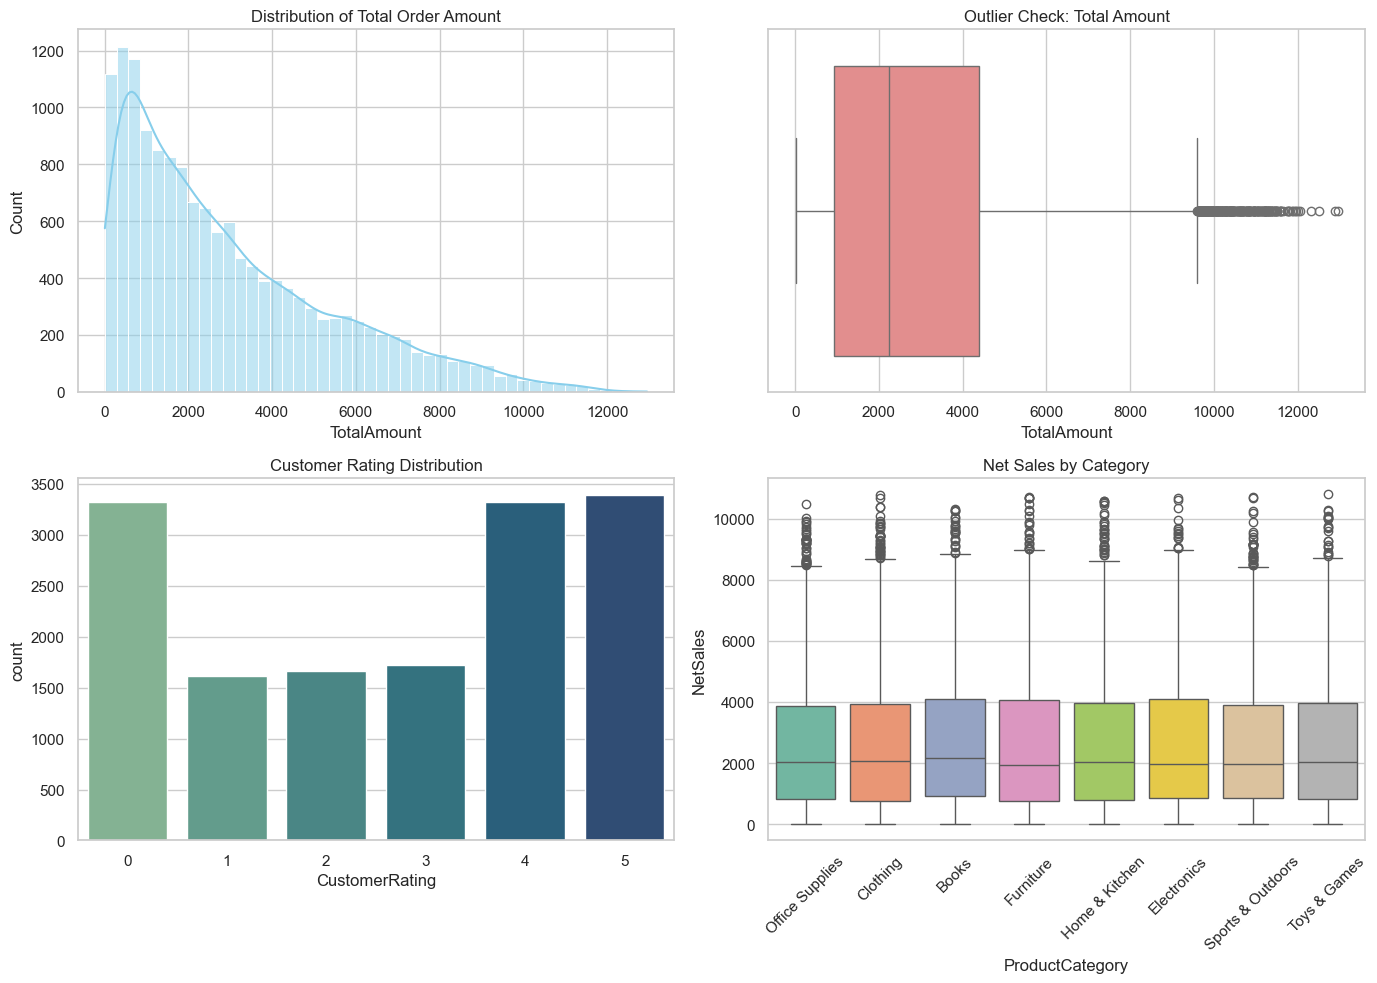

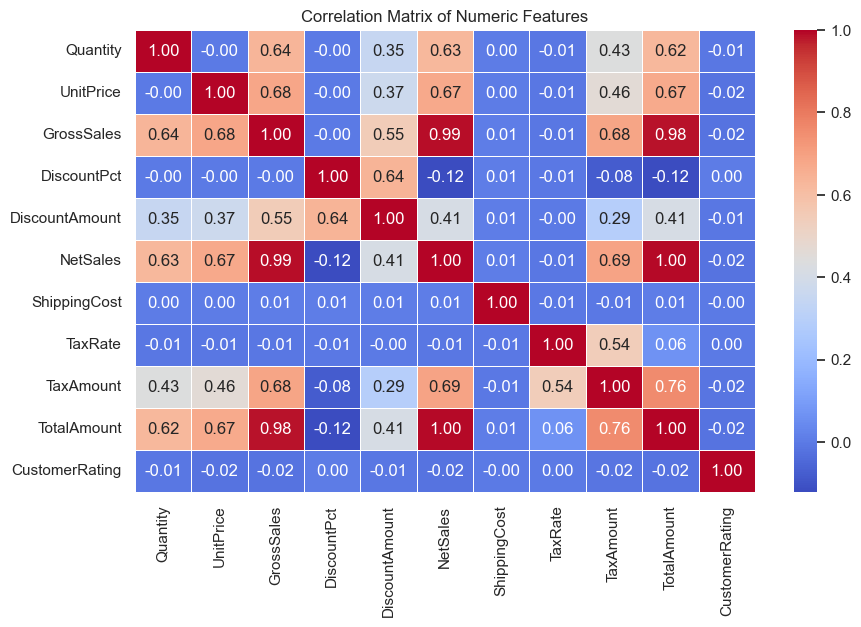

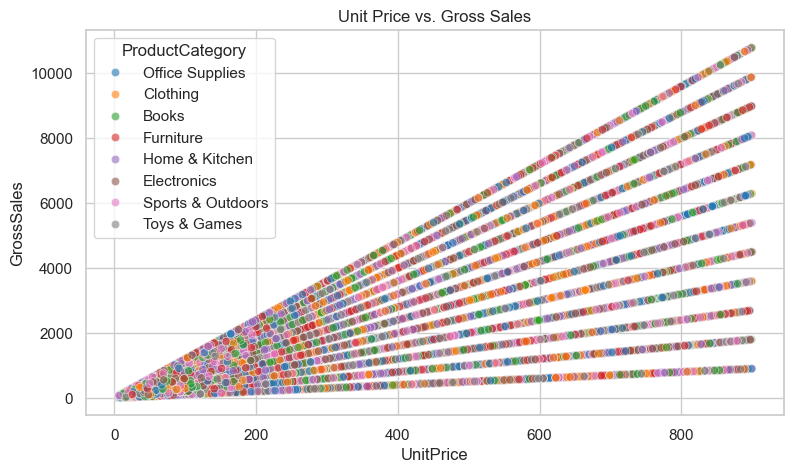

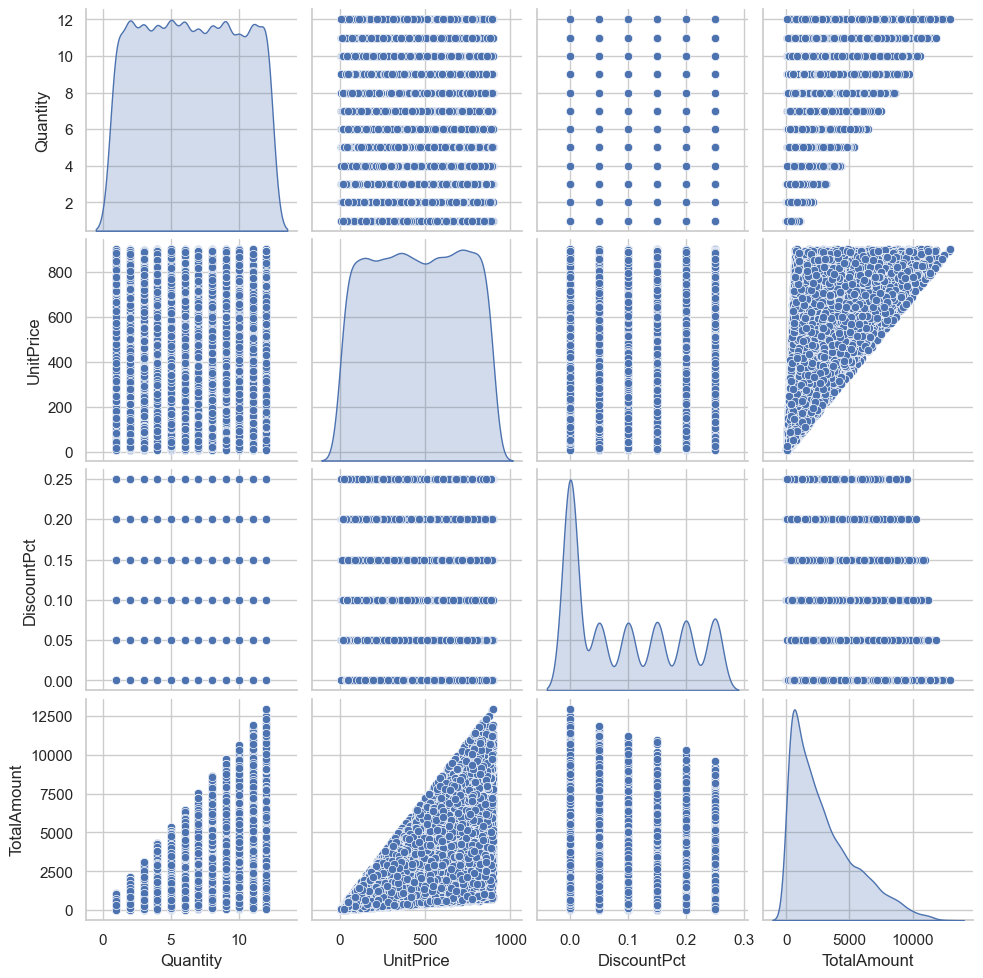

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


df = pd.read_csv('salesdataset.csv')


df.info()


df.describe()


df['Region'].value_counts()  

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['TotalAmount'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Total Order Amount')


sns.boxplot(x=df['TotalAmount'], ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Outlier Check: Total Amount')


sns.countplot(data=df, x='CustomerRating', ax=axes[1, 0], palette='crest')
axes[1, 0].set_title('Customer Rating Distribution')


sns.boxplot(
    data=df,
    x='ProductCategory',
    y='NetSales',
    ax=axes[1, 1],
    palette='Set2',
)
axes[1, 1].set_title('Net Sales by Category')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()   



plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()


plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x='UnitPrice',
    y='GrossSales',
    hue='ProductCategory',
    alpha=0.6,
    palette='tab10'
)
plt.title('Unit Price vs. Gross Sales')
plt.show() 


subset = df[['Quantity', 'UnitPrice', 'DiscountPct', 'TotalAmount']]
sns.pairplot(subset, diag_kind='kde')
plt.show()   




Summary of Findings & Exploratory Data Analysis
Key Insights

Sales & Revenue Distribution: Order amounts are distinctly right-skewed. While the median order amount is $2,244.64, the mean is higher at $2,961.19, driven by high-value transactions reaching up to $12,953.42.

Balanced Regional and Channel Performance: Revenue and order volume are evenly distributed across all six sales channels (ranging from 2,477 orders on Amazon to 2,548 on eBay) and geographical regions, indicating balanced market penetration without reliance on a single outlet.

Product Category Trends: "Books" generated the highest cumulative net sales ($5.28M across 1,896 orders), closely followed by "Office Supplies" ($5.15M across 1,953 orders).

Driver of Gross Sales: High positive correlation exists between UnitPrice, Quantity, and TotalAmount. By contrast, DiscountPct exhibits negligible correlation with CustomerRating (r≈0.003) and sales volumes, indicating discounts are not the primary driver for high customer satisfaction.

Data Quality Issues

Missing Data: The SalesRep feature contains 1,696 missing values (~11.3% of the 15,030 total records). This typically occurs on direct online/mobile self-service orders where no sales representative was assigned.

Duplicate Records: There are 30 exact duplicate rows present in the raw dataset that must be dropped prior to modeling to avoid bias.

Outliers: The TotalAmount and GrossSales metrics contain notable upper-bound outliers exceeding the 1.5 × IQR threshold, reflecting bulk business orders or premium item bundles.

Recommendations & Next Steps

Data Preprocessing:

Deduplicate the dataset by removing the 30 identical rows.

Impute missing values in SalesRep with a placeholder category like 'Unassigned' or 'Direct/Online'.

Apply a log transformation or robust scaling on TotalAmount and GrossSales to mitigate skewness before feeding into linear algorithms.

Feature Engineering:

Convert OrderDate to datetime objects and extract temporal components (Year, Month, Day of Week, Quarter) to model seasonality.

Construct a flag for discounted vs. non-discounted transactions to analyze discount sensitivity per category.

Predictive Modeling Suggestions:

Regression: Train a Random Forest or XGBoost Regressor to predict TotalAmount based on category, region, and channel.

Classification: Build a classification model (e.g., Logistic Regression or LightGBM) to predict order cancellation or return risks (OrderStatus in ['Cancelled', 'Returned']).